#### Tratamento e padronização dos dados

In [223]:
import pandas as pd
import matplotlib.pyplot as plt

In [224]:
df_arrivals = pd.read_csv('data/International Arrivals - Number of Tourists/international_arrivals_number_tourists.csv', skiprows=4)
df_paises = pd.read_csv('continentes.csv')

df_arrivals.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"International tourism, number of arrivals",ST.INT.ARVL,NaN,NaN,NaN,NaN,NaN,NaN,...,1.863000e+06,1.897000e+06,1.951000e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,"International tourism, number of arrivals",ST.INT.ARVL,NaN,NaN,NaN,NaN,NaN,NaN,...,3.825835e+07,4.118915e+07,3.982670e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,"International tourism, number of arrivals",ST.INT.ARVL,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,"International tourism, number of arrivals",ST.INT.ARVL,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,"International tourism, number of arrivals",ST.INT.ARVL,NaN,NaN,NaN,NaN,NaN,NaN,...,2.610000e+05,2.180000e+05,2.180000e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [225]:
df_arrivals.columns

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024', '2025', 'Unnamed: 70'],
      dtype='object')

In [226]:
#Removendo colunas desnecessarias
df_arrivals = df_arrivals.drop(columns=['Indicator Name', 'Indicator Code', 'Unnamed: 70'], axis=1)
df_arrivals.columns

Index(['Country Name', 'Country Code', '1960', '1961', '1962', '1963', '1964',
       '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973',
       '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982',
       '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991',
       '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000',
       '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009',
       '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018',
       '2019', '2020', '2021', '2022', '2023', '2024', '2025'],
      dtype='object')

In [227]:
df_arrivals.rename(columns={
    "Country Name": "País",
    "Country Code": "Sigla",
}, inplace=True)

df_arrivals.head()

,País,Sigla,1960,1961,1962,1963,1964,1965,1966,1967,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Aruba,ABW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.758000e+06,1.863000e+06,1.897000e+06,1.951000e+06,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.764589e+07,3.825835e+07,4.118915e+07,3.982670e+07,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.315078e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.970000e+05,2.610000e+05,2.180000e+05,2.180000e+05,NaN,NaN,NaN,NaN,NaN,NaN


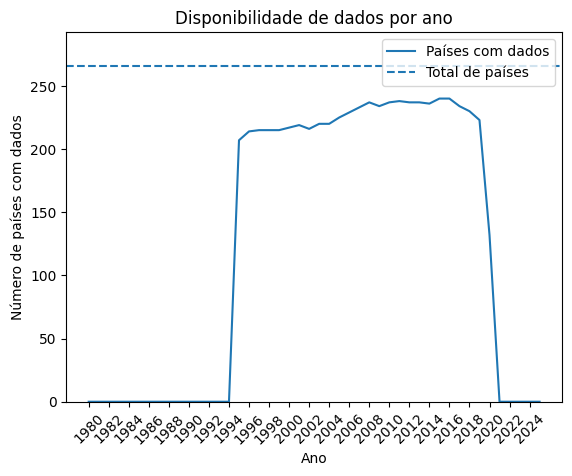

In [228]:
cols_anos = [col for col in df_arrivals.columns if col.isdigit() and 1980 <= int(col) <= 2025]
contagem = df_arrivals[cols_anos].notna().sum()
total_paises = len(df_arrivals)


plt.ylim(0, total_paises * 1.1)
plt.plot(contagem.index.astype(int), contagem.values, label="Países com dados")
anos = contagem.index.astype(int)
plt.xticks(anos[anos >= 1980][::2], rotation=45)  # de 2 em 2 anos
plt.axhline(y=total_paises, linestyle='--', label="Total de países")
plt.xlabel("Ano")
plt.ylabel("Número de países com dados")
plt.title("Disponibilidade de dados por ano")
plt.legend()
plt.show()


In [229]:
#selecionando apenas o intervalo com maior quantidade de dados, verificar se 2000 
cols_anos = [col for col in df_arrivals.columns if col.isdigit() and 2000 <= int(col) <= 2020]
cols_finais = ['País', 'Sigla'] + cols_anos
df_arrivals = df_arrivals[cols_finais]

#df_arrivals = df_arrivals.merge(
#    df_paises[['Sigla', 'Continente']],
#    left_on='Sigla',
#    right_on='Sigla',
#    how='left'
#)

#adicionando continentes e removendo os nao paises
df_arrivals = df_arrivals.merge(
    df_paises[['Sigla', 'Continente']],
    on='Sigla',
    how='inner'
)

#cols = ['País', 'sigla', 'Regiao', 'sub-region'] + [col for col in df_final.columns if col not in ['Country Name', 'Country Code', 'region', 'sub-region']]
cols = ['País', 'Sigla', 'Continente'] + [col for col in df_arrivals.columns if col not in ['País', 'Sigla', 'Continente']]

df_arrivals = df_arrivals[cols]

#df_arrivals.rename(columns={"region": "Continente"}, inplace=True)

df_arrivals.head()

,País,Sigla,Continente,2000,2001,2002,2003,2004,2005,2006,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,Aruba,ABW,NaN,1211000.0,1178000.0,1225000.0,1184000.0,1304000.0,1286000.0,1285000.0,...,1469000.0,1481000.0,1667000.0,1739000.0,1832000.0,1758000.0,1863000.0,1897000.0,1951000.0,NaN
1,Afghanistan,AFG,AS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Angola,AGO,AF,51000.0,67000.0,91000.0,107000.0,194000.0,210000.0,121000.0,...,481000.0,528000.0,650000.0,595000.0,592000.0,397000.0,261000.0,218000.0,218000.0,NaN
3,Albania,ALB,EU,317000.0,354000.0,470000.0,557000.0,645000.0,748000.0,937000.0,...,2932000.0,3514000.0,3256000.0,3673000.0,4131000.0,4736000.0,5118000.0,5927000.0,6406000.0,2658000.0
4,Andorra,AND,EU,10991000.0,11351000.0,11507000.0,11601000.0,11668000.0,11049000.0,10737000.0,...,7983000.0,7900000.0,7676000.0,7797000.0,7850000.0,8025000.0,8152000.0,8328000.0,8235000.0,5207000.0


In [230]:
cols_anos = sorted(
    [col for col in df_arrivals.columns if col.isdigit() and int(col) > 2000],
    key=int
)

contagem_linhas = df_arrivals[cols_anos].notna().sum(axis=1)

# Criterio de remoção: se tiver mais de 14 dados não remove, ajustar se necessario
mask = contagem_linhas >= 14

removidos = df_arrivals.loc[~mask, ['País'] + cols_anos].copy()
removidos['qtd_dados'] = contagem_linhas[~mask]

# remove todos os paises que não tem mais de 14 anos com dados
df_arrivals = df_arrivals[mask]


#contagem = df_arrivals[cols_anos].notna().sum()
#total_paises = len(df_arrivals)

removidos

#df_arrivals

,País,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,qtd_dados
1,Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
5,United Arab Emirates,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.931300e+07,2.089400e+07,21805000.0,23092000.0,25282000.0,8.084000e+06,6
28,Brunei Darussalam,8.400000e+05,891000.0,9.440000e+05,NaN,8.150000e+05,8.360000e+05,8.770000e+05,NaN,NaN,...,NaN,NaN,NaN,NaN,4.257000e+06,4316000.0,4521000.0,4449000.0,1.071000e+06,11
30,Botswana,1.451000e+06,1485000.0,1.592000e+06,1.727000e+06,1.684000e+06,1.642000e+06,1.965000e+06,2344000.0,NaN,...,NaN,NaN,NaN,1.660000e+06,1.712000e+06,1775000.0,1830000.0,NaN,NaN,12
34,Chile,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3713000.0,3657000.0,...,4397000.0,4457000.0,4.601000e+06,5.487000e+06,6.712000e+06,7621000.0,6603000.0,5431000.0,NaN,12
39,"Congo, Rep.",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,259000.0,345000.0,2.290000e+05,2.240000e+05,2.130000e+05,151000.0,158000.0,NaN,NaN,9
50,Djibouti,2.160000e+04,22500.0,2.320000e+04,2.630000e+04,3.020000e+04,3.950000e+04,4.000000e+04,54000.0,58000.0,...,60000.0,63000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13
64,Faroe Islands,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
66,Gabon,2.360000e+05,269000.0,2.340000e+05,3.510000e+05,5.260000e+05,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
70,Gibraltar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [231]:
#verificando se existe algum pais com valores negativos
df_arrivals[df_arrivals[cols_anos].lt(0).any(axis=1)]

,País,Sigla,Continente,2000,2001,2002,2003,2004,2005,2006,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020


In [232]:
df_arrivals[cols_anos].isna().sum().sum()

np.int64(171)

In [233]:
#Exportação dos dados filtrados
import os

# nome do arquivo
caminho_saida = "data/International Arrivals - Number of Tourists/international_arrivals_number_tourists.csv"

# salvar
df_arrivals.to_csv(caminho_saida, index=False, encoding='utf-8-sig')

### **Estrutura de dados**

| Coluna        | Tipo   | Descrição                                                   |
|--------------|--------|-------------------------------------------------------------|
| País         | String | Nome do país                                                |
| Continente   | String | Continente ao qual o país pertence                                              |
| Sigla        | String | Código ISO alpha-3 do país                                  |
| 2000 a 2020  | numérico  | Número total de chegadas de turistas internacionais no ano  |